In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "whitegrid")
warnings.filterwarnings("ignore")

In [3]:
# reading the data
movies = pd.read_fwf("../data/movies.dat", encoding = "ISO-8859-1")
movies.head()

,Movie ID::Title::Genres,Unnamed: 1,Unnamed: 2
0,1::Toy Story (1995)::Animation|Children's|Comedy,NaN,NaN
1,2::Jumanji (1995)::Adventure|Children's|Fantasy,NaN,NaN
2,3::Grumpier Old Men (1995)::Comedy|Romance,NaN,NaN
3,4::Waiting to Exhale (1995)::Comedy|Drama,NaN,NaN
4,5::Father of the Bride Part II (1995)::Comedy,NaN,NaN


In [4]:
ratings = pd.read_fwf("../data/ratings.dat", encoding = "ISO-8859-1")
ratings.head()

,UserID::MovieID::Rating::Timestamp
0,1::1193::5::978300760
1,1::661::3::978302109
2,1::914::3::978301968
3,1::3408::4::978300275
4,1::2355::5::978824291


In [5]:
users = pd.read_fwf("../data/users.dat", encoding = "ISO-8859-1")
users.head()

,UserID::Gender::Age::Occupation::Zip-code
0,1::F::1::10::48067
1,2::M::56::16::70072
2,3::M::25::15::55117
3,4::M::45::7::02460
4,5::M::25::20::55455


In [6]:
# formatting the movies data
movies.drop(columns = ["Unnamed: 1", "Unnamed: 2"], inplace = True)
movies.head()

,Movie ID::Title::Genres
0,1::Toy Story (1995)::Animation|Children's|Comedy
1,2::Jumanji (1995)::Adventure|Children's|Fantasy
2,3::Grumpier Old Men (1995)::Comedy|Romance
3,4::Waiting to Exhale (1995)::Comedy|Drama
4,5::Father of the Bride Part II (1995)::Comedy


In [7]:
movies = movies["Movie ID::Title::Genres"].str.split("::", expand = True)
movies.columns = ["MovieID", "Title", "Genres"]
movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
# sampling 10 rows to perform a quick check if the manipulation has worked
movies.sample(10)

,MovieID,Title,Genres
1073,1089,Reservoir Dogs (1992),Crime|Thriller
3460,3529,"Postman Always Rings Twice, The (1981)",Crime|Thriller
1028,1041,Secrets & Lies (1996),Drama
189,191,"Scarlet Letter, The (1995)",Drama
959,971,Cat on a Hot Tin Roof (1958),Drama
1518,1557,Squeeze (1996),Drama
1847,1916,Buffalo 66 (1998),Action|Comedy|Drama
607,611,Hellraiser: Bloodline (1996),Action|Horror|Sci-Fi
2494,2563,Beauty (1998),Drama
965,977,Moonlight Murder (1936),Mystery


In [9]:
# formatting the ratings data
ratings = ratings["UserID::MovieID::Rating::Timestamp"].str.split("::", expand = True)
ratings.columns = ["UserID", "MovieID", "Rating", "Timestamp"]
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [10]:
# sampling 10 rows to perform a quick check if the manipulation has worked
ratings.sample(10)

,UserID,MovieID,Rating,Timestamp
630999,3817,1960,4,965950211
444541,2743,1647,3,973221463
591002,3605,1387,3,966615872
258764,1585,150,3,974736305
524901,3240,2770,5,968350746
794268,4748,3784,3,1031075898
772016,4601,2628,4,964206572
902217,5453,1358,5,1029360059
863071,5196,1020,2,961694078
243722,1470,3090,1,974838711


In [11]:
# formatting the users data
users = users["UserID::Gender::Age::Occupation::Zip-code"].str.split("::", expand = True)
users.columns = ["UserID", "Gender", "Age", "Occupation", "Zipcode"]
users.head()

,UserID,Gender,Age,Occupation,Zipcode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [12]:
# formatting the "Age" and the "Occupation" column
users.replace({
    "Age": {
        "1": "Under 18",
        "18": "18-24",
        "25": "25-34",
        "35": "35-44",
        "45": "45-49",
        "50": "50-55",
        "56": "56+"
    },
    "Occupation": {
        "0": "other",
        "1": "academic/educator",
        "2": "artist",
        "3": "clerical/admin",
        "4": "college/grad student",
        "5": "customer service",
        "6": "doctor/health care",
        "7": "executive/managerial",
        "8": "farmer",
        "9": "homemaker",
        "10": "K-12 student",
        "11": "lawyer",
        "12": "programmer",
        "13": "retired",
        "14": "sales/marketing",
        "15": "scientist",
        "16": "self-employed",
        "17": "technician/engineer",
        "18": "tradesman/craftsman",
        "19": "unemployed",
        "20": "writer"
    }
}, inplace = True)

In [13]:
# sampling 10 rows to perform a quick check if the manipulation has worked
users.sample(10)

,UserID,Gender,Age,Occupation,Zipcode
4541,4542,M,35-44,other,94610
4174,4175,M,35-44,other,66204
5104,5105,M,50-55,executive/managerial,18977
3909,3910,M,25-34,writer,91505
59,60,M,50-55,academic/educator,72118
3011,3012,M,25-34,programmer,78660
5160,5161,M,25-34,college/grad student,30052
3332,3333,M,18-24,self-employed,29404-2205
1389,1390,M,35-44,self-employed,99352
4960,4961,M,25-34,executive/managerial,46220


In [14]:
# merging the data files and creating a single consolidated DataFrame

# merging movies and ratings 
movies_ratings = pd.merge(movies, ratings, how = "inner", on = "MovieID")
movies_ratings.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,978824268
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,978237008
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,978233496
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,978225952
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,978226474


In [15]:
# merging movies_ratings and users
df = pd.merge(movies_ratings, users, how = "inner", on = "UserID")
df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp,Gender,Age,Occupation,Zipcode
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,978824268,F,Under 18,K-12 student,48067
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,978237008,F,50-55,homemaker,55117
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,978233496,M,25-34,programmer,11413
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,978225952,M,25-34,technician/engineer,61614
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,978226474,F,35-44,academic/educator,95370


In [16]:
# sampling 10 rows to perform a quick check if the merging has worked
df.sample(10)

,MovieID,Title,Genres,UserID,Rating,Timestamp,Gender,Age,Occupation,Zipcode
415109,1396,Sneakers (1992),Crime|Drama|Sci-Fi,4268,5,965304766,F,45-49,writer,04046
66086,253,Interview with the Vampire (1994),Drama|Horror,709,4,975540537,M,18-24,other,92647
522002,1952,Midnight Cowboy (1969),Drama,4506,4,964984381,M,50-55,self-employed,29464
228796,924,2001: A Space Odyssey (1968),Drama|Mystery|Sci-Fi|Thriller,166,5,977186372,M,18-24,college/grad student,92802
371222,1287,Ben-Hur (1959),Action|Adventure|Drama,5317,5,972355981,F,25-34,other,02138
863858,3252,Scent of a Woman (1992),Drama,5775,4,958167424,M,25-34,lawyer,10024
774369,2879,Operation Condor (Feiying gaiwak) (1990),Action|Adventure|Comedy,2175,3,974610552,M,25-34,college/grad student,99217
675014,2475,52 Pick-Up (1986),Action|Mystery|Thriller,4277,5,965647229,M,35-44,self-employed,98133
463062,1641,"Full Monty, The (1997)",Comedy,1866,4,974834563,M,25-34,executive/managerial,94043
883773,3359,Breaking Away (1979),Drama,402,4,976294877,M,25-34,lawyer,55427


In [17]:
# eda, data cleaning and feature engineering

# shape of the dataset
df.shape

(1000209, 10)

In [18]:
# structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   MovieID     1000209 non-null  object
 1   Title       1000209 non-null  object
 2   Genres      996144 non-null   object
 3   UserID      1000209 non-null  object
 4   Rating      1000209 non-null  object
 5   Timestamp   1000209 non-null  object
 6   Gender      1000209 non-null  object
 7   Age         1000209 non-null  object
 8   Occupation  1000209 non-null  object
 9   Zipcode     1000209 non-null  object
dtypes: object(10)
memory usage: 76.3+ MB


In [19]:
# missing values in the dataset
df.isna().sum()

MovieID          0
Title            0
Genres        4065
UserID           0
Rating           0
Timestamp        0
Gender           0
Age              0
Occupation       0
Zipcode          0
dtype: int64

In [20]:
# unique values in each column
for i in df.columns:
    print(f"Unique Values in {i} Column:")
    print(df[i].unique())
    print()

Unique Values in MovieID Column:
['1' '2' '3' ... '3950' '3951' '3952']

Unique Values in Title Column:
['Toy Story (1995)' 'Jumanji (1995)' 'Grumpier Old Men (1995)' ...
 'Tigerland (2000)' 'Two Family House (2000)' 'Contender, The (2000)']

Unique Values in Genres Column:
["Animation|Children's|Comedy" "Adventure|Children's|Fantasy"
 'Comedy|Romance' 'Comedy|Drama' 'Comedy' 'Action|Crime|Thriller'
 "Adventure|Children's" 'Action' 'Action|Adventure|Thriller'
 'Comedy|Drama|Romance' 'Comedy|Horror' "Animation|Children's" 'Drama'
 'Action|Adventure|Romance' 'Drama|Thriller' 'Drama|Romance' 'Thriller'
 'Action|Comedy|Drama' 'Crime|Drama|Thriller' 'Drama|Sci-Fi' 'Romance'
 'Adventure|Sci-Fi' 'Adventure|Romance' "Children's|Comedy|Drama"
 'Documentary' 'Drama|War' 'Action|Crime|Drama' 'Action|Adventure'
 'Crime|Thriller' "Animation|Children's|Musical|Romance"
 "Children's|Comedy" 'Drama|Mystery' None 'Sci-Fi|Thriller'
 'Action|Comedy|Crime|Horror|Thriller' 'Drama|Musical'
 'Crime|Drama|Rom

In [21]:
# converting the data type of "Rating" column from object to int32
df["Rating"] = df["Rating"].astype("int32")

In [22]:
# converting the data type of "Timestamp" column from object to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit = "s")

In [23]:
# extracting the release year from the "Title" column
df["release_year"] = df['Title'].str.extract(r"\((\d{4})\)")
df["release_year"] = df["release_year"].str.lstrip("()").str.rstrip(")")

In [24]:
# dropping all the rows with missing values
df.dropna(inplace = True)
df.isna().sum()

MovieID         0
Title           0
Genres          0
UserID          0
Rating          0
Timestamp       0
Gender          0
Age             0
Occupation      0
Zipcode         0
release_year    0
dtype: int64

In [25]:
# converting the data type of "release_year" column to int32
df["release_year"] = df["release_year"].astype("int32")

In [26]:
# removing the year from the "Title" column
df["Title"] = df["Title"].str.replace(r" \(\d{4}\)", "", regex=True)

In [27]:
# creating a bin for the decade in which the movie was released in
bins = [1919, 1929, 1939, 1949, 1959, 1969, 1979, 1989, 2000]
labels = ["20s", "30s", "40s", "50s", "60s", "70s", "80s", "90s"]
df["release_decade"] = pd.cut(df["release_year"], bins = bins, labels = labels)
df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp,Gender,Age,Occupation,Zipcode,release_year,release_decade
0,1,Toy Story,Animation|Children's|Comedy,1,5,2001-01-06 23:37:48,F,Under 18,K-12 student,48067,1995,90s
1,1,Toy Story,Animation|Children's|Comedy,6,4,2000-12-31 04:30:08,F,50-55,homemaker,55117,1995,90s
2,1,Toy Story,Animation|Children's|Comedy,8,4,2000-12-31 03:31:36,M,25-34,programmer,11413,1995,90s
3,1,Toy Story,Animation|Children's|Comedy,9,5,2000-12-31 01:25:52,M,25-34,technician/engineer,61614,1995,90s
4,1,Toy Story,Animation|Children's|Comedy,10,5,2000-12-31 01:34:34,F,35-44,academic/educator,95370,1995,90s


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996144 entries, 0 to 1000208
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   MovieID         996144 non-null  object        
 1   Title           996144 non-null  object        
 2   Genres          996144 non-null  object        
 3   UserID          996144 non-null  object        
 4   Rating          996144 non-null  int32         
 5   Timestamp       996144 non-null  datetime64[ns]
 6   Gender          996144 non-null  object        
 7   Age             996144 non-null  object        
 8   Occupation      996144 non-null  object        
 9   Zipcode         996144 non-null  object        
 10  release_year    996144 non-null  int32         
 11  release_decade  996099 non-null  category      
dtypes: category(1), datetime64[ns](1), int32(2), object(8)
memory usage: 84.6+ MB


In [29]:
df.sample(10)

,MovieID,Title,Genres,UserID,Rating,Timestamp,Gender,Age,Occupation,Zipcode,release_year,release_decade
517018,1927,All Quiet on the Western Front,War,1613,4,2000-11-22 15:15:48,M,18-24,writer,61801,1930,30s
403437,1376,Star Trek IV: The Voyage Home,Action|Adventure|Sci-Fi,3626,4,2000-08-18 13:58:21,M,25-34,technician/engineer,75075,1986,80s
849263,3175,Galaxy Quest,Adventure|Comedy|Sci-Fi,851,3,2000-11-27 18:15:54,M,18-24,college/grad student,75287,1999,90s
228222,923,Citizen Kane,Drama,3288,4,2001-01-18 20:00:24,M,25-34,sales/marketing,94133,1941,40s
557427,2028,Saving Private Ryan,Action|Drama|War,5686,5,2000-05-17 22:30:58,M,56+,self-employed,60610,1998,90s
979167,3793,X-Men,Action|Sci-Fi,4235,5,2000-08-03 14:36:53,M,50-55,artist,90029,2000,90s
472768,1676,Starship Troopers,Action|Adventure|Sci-Fi|War,5865,2,2000-05-06 22:58:49,M,25-34,technician/engineer,95926,1997,90s
457347,1617,L.A. Confidential,Crime|Film-Noir|Mystery|Thriller,3093,5,2000-09-22 19:28:50,F,45-49,writer,89134,1997,90s
751312,2779,Heaven Can Wait,Comedy,4928,5,2000-07-04 00:12:46,F,25-34,clerical/admin,92103,1978,70s
405299,1378,Young Guns,Action|Comedy|Western,3910,3,2000-08-08 17:32:35,M,25-34,writer,91505,1988,80s


In [30]:
# modifying the column names
df.rename(columns = {
    "MovieID": "movie_id",
    "Title": "title",
    "Genres": "genres",
    "UserID": "user_id",
    "Rating": "rating",
    "Timestamp": "timestamp",
    "Gender": "gender",
    "Age": "age",
    "Occupation": "occupation",
    "Zipcode": "zip_code",
    "release_year": "release_year",
    "release_decade": "release_decade"
}, inplace = True)
df.head()

,movie_id,title,genres,user_id,rating,timestamp,gender,age,occupation,zip_code,release_year,release_decade
0,1,Toy Story,Animation|Children's|Comedy,1,5,2001-01-06 23:37:48,F,Under 18,K-12 student,48067,1995,90s
1,1,Toy Story,Animation|Children's|Comedy,6,4,2000-12-31 04:30:08,F,50-55,homemaker,55117,1995,90s
2,1,Toy Story,Animation|Children's|Comedy,8,4,2000-12-31 03:31:36,M,25-34,programmer,11413,1995,90s
3,1,Toy Story,Animation|Children's|Comedy,9,5,2000-12-31 01:25:52,M,25-34,technician/engineer,61614,1995,90s
4,1,Toy Story,Animation|Children's|Comedy,10,5,2000-12-31 01:34:34,F,35-44,academic/educator,95370,1995,90s


In [31]:
# checking for the presence of duplicates
df.duplicated().sum()

0

In [32]:
# checking for the presence of missing values
df.isna().sum()

movie_id           0
title              0
genres             0
user_id            0
rating             0
timestamp          0
gender             0
age                0
occupation         0
zip_code           0
release_year       0
release_decade    45
dtype: int64

In [33]:
# dropping the missing values
df.dropna(inplace = True)
df.isna().sum()

movie_id          0
title             0
genres            0
user_id           0
rating            0
timestamp         0
gender            0
age               0
occupation        0
zip_code          0
release_year      0
release_decade    0
dtype: int64

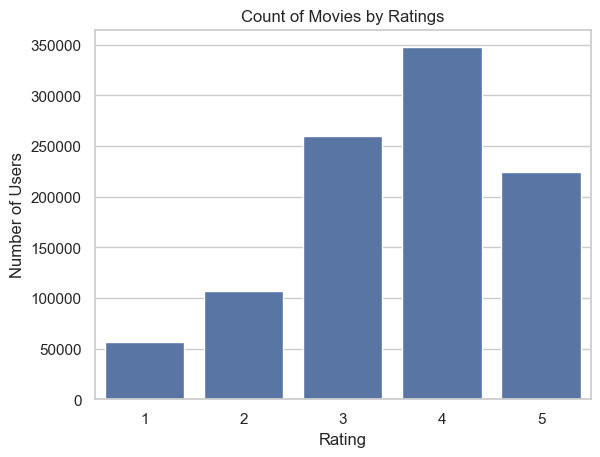

In [34]:
# graphical analysis

# count plot of movies by ratings
sns.countplot(x = "rating", data = df)
plt.xlabel("Rating")
plt.ylabel("Number of Users")
plt.title("Count of Movies by Ratings")
plt.savefig("../artifacts/count_plot_of_movies_by_ratings.png")
plt.show()

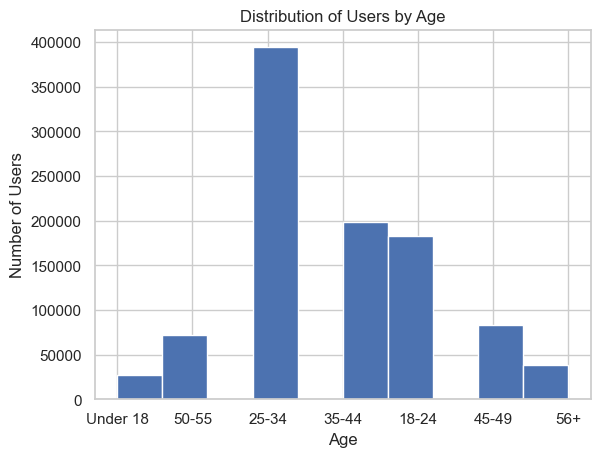

In [35]:
# distribution of users by age
df["age"].hist()
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Distribution of Users by Age")
plt.savefig("../artifacts/distribution_of_users_by_age.png")
plt.show()

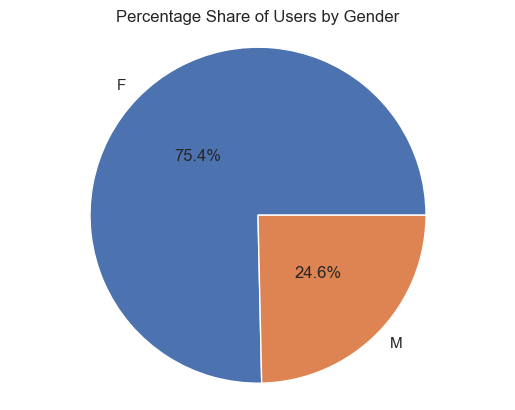

In [36]:
# percentage share of users by gender
plt.pie(df["gender"].value_counts().values, center = (0, 0), labels = df["gender"].unique(), autopct = "%1.1f%%", pctdistance = 0.5)
plt.title("Percentage Share of Users by Gender")
plt.axis("equal")
plt.savefig("../artifacts/percentage_share_of_users_by_gender.png")
plt.show()

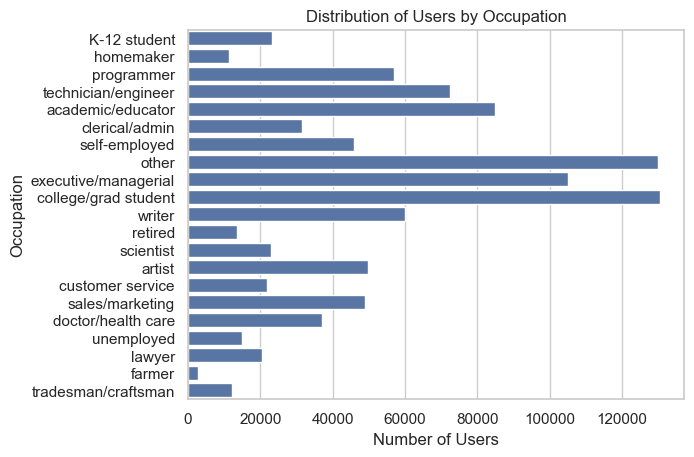

In [37]:
# distribution of users by occupation
sns.countplot(y = "occupation", data = df)
plt.xlabel("Number of Users")
plt.ylabel("Occupation")
plt.title("Distribution of Users by Occupation")
plt.savefig("../artifacts/distribution_of_users_by_occupation.png")
plt.show()

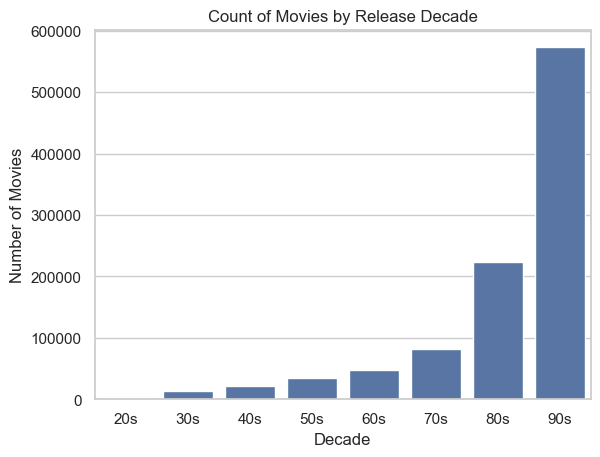

In [38]:
# count of movies by release decade
sns.countplot(x = "release_decade", data = df)
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.title("Count of Movies by Release Decade")
plt.savefig("../artifacts/count_of_movies_by_release_decade.png")
plt.show()

In [39]:
df.to_csv("../data/data_cleaned.csv")